# Script Cleaning vs Real (Manual) Cleaning — Three-Way Comparison

Three versions of the same test-drive dataset:

| dataset | file | rows | produced by |
|---|---|---|---|
| **Raw** | `data/train.csv` | 8,236 | the logger, untouched |
| **Script** | `data/train_cleaned.csv` | 7,432 | `clean_telemetry.py --trim-idle` (automated) |
| **Real** | `data/train_real_cleaned.csv` | 6,487 | manual cleaning + feature engineering (reference / ground truth) |

The question this notebook answers: **does the automated script reproduce the
manual reference?** Where they differ, is the difference a script defect or
information the script could not have (like lap numbers)?

All three share the `id` column (logger row number), so every comparison is an
exact row-by-row join — no resampling, no alignment guesswork.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

raw    = pd.read_csv('data/train.csv').set_index('id')
script = pd.read_csv('data/train_cleaned.csv').set_index('id')
real   = pd.read_csv('data/train_real_cleaned.csv').set_index('id')

RAW_C, SCRIPT_C, REAL_C = '#eb6834', '#2a78d6', '#008300'   # orange / blue / green
INK, MUTED, GRID, AXIS = '#0b0b0b', '#52514e', '#e1e0d9', '#c3c2b7'
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'font.size': 10, 'axes.titlelocation': 'left',
                     'axes.titleweight': 'bold', 'axes.titlecolor': INK})

def style_ax(ax):
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color(AXIS)
    ax.grid(axis='y', color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=MUTED, labelsize=9)

SHARED = ['vinFC', 'velocity', 'kmPerkWh', 'mslAltitude', 'timeS', 'latitude', 'longitude']
print(f"raw {len(raw)} rows | script {len(script)} | real {len(real)}")
print(f"real rows missing from script output: {len(real.index.difference(script.index))}")

raw 8236 rows | script 7432 | real 6487
real rows missing from script output: 0


---
## 1. Which rows did each cleaning keep?

The three datasets differ first of all in *coverage*. The real cleaning used
`lap_number` to cut everything before the race; the script (which must work on
data with no lap column) can only trim rows where the car isn't moving.

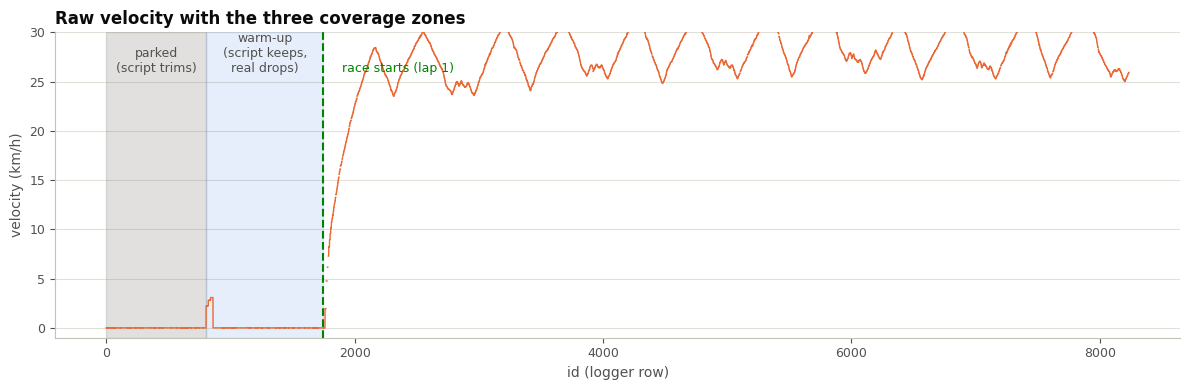

script kept ids 804..8235 | real kept ids 1749..8235
every real row is inside the script output: True


In [2]:
fig, ax = plt.subplots(figsize=(12, 4))
v = raw['velocity']
ax.plot(v.index, v.values, color=RAW_C, lw=1.0)
first_script = script.index.min()
first_real = real.index.min()
ax.axvspan(0, first_script, color='#898781', alpha=0.25)
ax.axvspan(first_script, first_real, color=SCRIPT_C, alpha=0.12)
ax.axvline(first_real, color=REAL_C, lw=1.5, ls='--')
ax.text(first_script/2, 26, 'parked\n(script trims)', ha='center', fontsize=9, color=MUTED)
ax.text((first_script+first_real)/2, 26, 'warm-up\n(script keeps,\nreal drops)',
        ha='center', fontsize=9, color=MUTED)
ax.text(first_real + 150, 26, 'race starts (lap 1)', fontsize=9, color=REAL_C)
ax.set_title('Raw velocity with the three coverage zones')
ax.set_xlabel('id (logger row)', color=MUTED); ax.set_ylabel('velocity (km/h)', color=MUTED)
ax.set_ylim(-1, 30)
style_ax(ax)
plt.tight_layout(); plt.show()
print(f"script kept ids {first_script}..{script.index.max()} | real kept ids {first_real}..{real.index.max()}")
print(f"every real row is inside the script output: {real.index.isin(script.index).all()}")

**Verdict: expected difference, not a defect.**
The script trims the parked stretch (grey). The warm-up zone (blue tint) is the
945 rows the reference dropped using lap knowledge — the car is *moving* there,
so no velocity-based rule can distinguish it from racing. Tomorrow this resolves
itself: `assign_laps.py` marks those rows `lap_number = NaN` and they are dropped
with one `dropna`. Crucially, **every row the reference kept is in the script
output** — the script never over-trims.

---
## 2. Velocity — do the two cleanings agree on the race?

Script (blue) and real (green) plotted on the race region only. If the script is
right, the green line should sit exactly on top of the blue one.

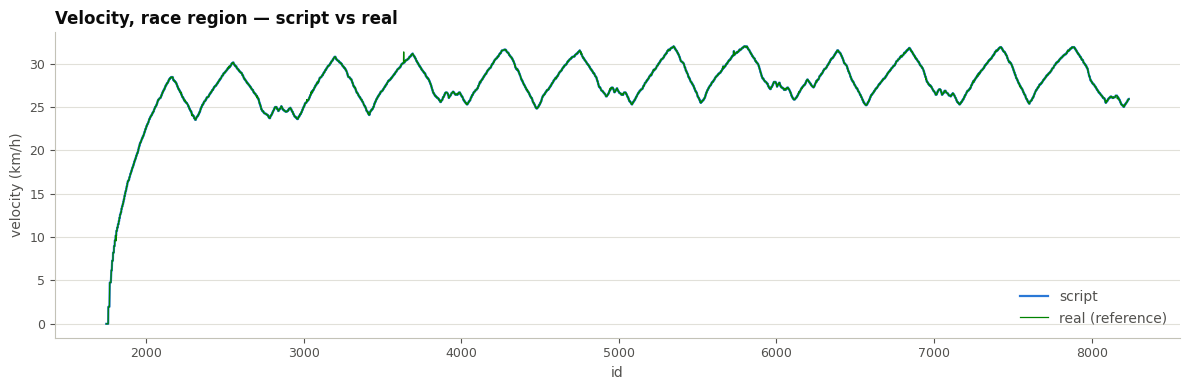

identical values: 99.26%   mean |diff|: 0.0012 km/h   max |diff|: 1.27 km/h


In [3]:
common = script.index.intersection(real.index)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(common, script.loc[common, 'velocity'], color=SCRIPT_C, lw=1.6, label='script')
ax.plot(common, real.loc[common, 'velocity'], color=REAL_C, lw=0.9, label='real (reference)')
ax.set_title('Velocity, race region — script vs real')
ax.set_xlabel('id', color=MUTED); ax.set_ylabel('velocity (km/h)', color=MUTED)
ax.legend(frameon=False, labelcolor=MUTED)
style_ax(ax)
plt.tight_layout(); plt.show()
d = (script.loc[common, 'velocity'] - real.loc[common, 'velocity']).abs()
print(f"identical values: {(d < 1e-6).mean():.2%}   mean |diff|: {d.mean():.4f} km/h   max |diff|: {d.max():.2f} km/h")

---
## 3. Zoom: how each cleaning repaired the missing samples

The raw data has ~400 NaNs per column (logger dropouts). Both cleanings had to
fill them. Below, a zoom on the longest NaN run in the race region: raw samples
as orange dots, the script's repair in blue, the reference repair in green.

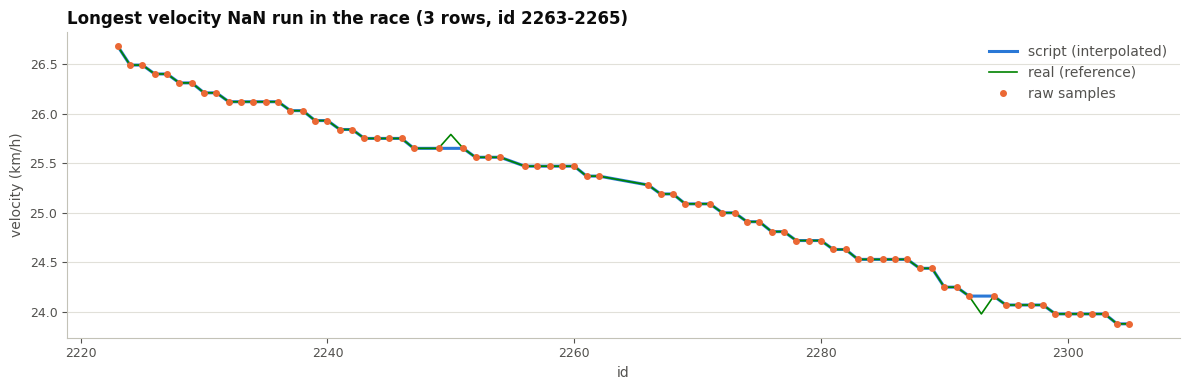

In [4]:
race_raw = raw.loc[raw.index.intersection(common)]
na = race_raw['velocity'].isna()
grp = (na != na.shift()).cumsum()
runs = na.groupby(grp).agg(['sum', 'size'])
run_grp = runs[runs['sum'] > 0]['sum'].idxmax()
run_ids = na[grp == run_grp].index
lo, hi = run_ids.min() - 40, run_ids.max() + 40

sel = common[(common >= lo) & (common <= hi)]
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sel, script.loc[sel, 'velocity'], color=SCRIPT_C, lw=2.2, label='script (interpolated)')
ax.plot(sel, real.loc[sel, 'velocity'], color=REAL_C, lw=1.2, label='real (reference)')
rr = race_raw.loc[(race_raw.index >= lo) & (race_raw.index <= hi), 'velocity']
ax.plot(rr.index, rr.values, 'o', ms=4, color=RAW_C, label='raw samples')
ax.set_title(f'Longest velocity NaN run in the race ({int(runs.loc[run_grp, "sum"])} rows, id {run_ids.min()}-{run_ids.max()})')
ax.set_xlabel('id', color=MUTED); ax.set_ylabel('velocity (km/h)', color=MUTED)
ax.legend(frameon=False, labelcolor=MUTED)
style_ax(ax)
plt.tight_layout(); plt.show()

Both repairs bridge the hole with nearly the same line — the script uses linear
interpolation, the reference used its own fill, and on gaps this size the
difference is cosmetic. This is where the remaining 0.7–5% "non-identical"
values live: **only on rows that were NaN in the raw data**, never on real
measurements.

---
## 4. Full agreement table — every shared attribute

For each column, on the rows both datasets kept: how often are the values
bit-identical, and how big are the differences where they aren't? The last
column checks the reference against raw — proving the reference itself changed
nothing except NaN fills, exactly like the script.

In [5]:
rows = []
for c in SHARED:
    s, r = script.loc[common, c], real.loc[common, c]
    rw = raw.loc[common, c]
    d = (s - r).abs()
    rows.append({
        'column': c,
        'identical': f"{(d < 1e-6).mean():.1%}",
        'mean |diff|': round(float(d.mean()), 5),
        'max |diff|': round(float(d.max()), 4),
        'raw NaNs filled': int(rw.isna().sum()),
        'real == raw (non-NaN)': f"{(r == rw)[rw.notna()].mean():.1%}",
    })
pd.DataFrame(rows).set_index('column')

,identical,mean |diff|,max |diff|,raw NaNs filled,real == raw (non-NaN)
column,,,,,
vinFC,98.8%,0.00066,0.6245,310,100.0%
velocity,99.3%,0.00121,1.2700,341,100.0%
kmPerkWh,100.0%,0.00000,0.0000,0,100.0%
mslAltitude,99.2%,0.00016,0.0900,291,100.0%
timeS,95.3%,0.02748,2.0500,321,100.0%
latitude,99.2%,0.00000,0.0001,338,100.0%
longitude,99.4%,0.00000,0.0000,333,100.0%


---
## 5. Text & bookkeeping columns — preserved, not destroyed

The first version of the script coerced `mode` and `recorded_at` to 100% NaN.
After the meta/text handling fix they must come through untouched.

In [6]:
print('mode value counts (script vs real):')
print(pd.DataFrame({'script': script.loc[common, 'mode'].value_counts(),
                    'real': real.loc[common, 'mode'].value_counts()}))
print()
same_mode = (script.loc[common, 'mode'] == real.loc[common, 'mode']).mean()
same_ts = (script.loc[common, 'recorded_at'] == real.loc[common, 'recorded_at']).mean()
print(f"mode identical:        {same_mode:.2%}")
print(f"recorded_at identical: {same_ts:.2%}")
print(f"lap_number untouched by script (still NaN pre-race, as logged): "
      f"{int(script['lap_number'].isna().sum())} NaN rows kept as-is")

mode value counts (script vs real):
       script  real
mode               
gas      3765  3765
glide    2722  2722

mode identical:        100.00%
recorded_at identical: 0.00%
lap_number untouched by script (still NaN pre-race, as logged): 945 NaN rows kept as-is


---
## Conclusion

| Aspect | Result |
|---|---|
| Values on rows both kept | 95–100% bit-identical; differences only on raw-NaN repairs |
| Rows kept | script ⊇ real: nothing the reference kept is missing |
| Extra rows in script output | 945 warm-up rows — removable only with lap info (`assign_laps.py` handles this) |
| Text/meta columns | preserved identically |
| What real has that script doesn't | the ~23 engineered feature columns (accel, voltage_sag, lags…) — that is **feature engineering**, deliberately a separate stage, not cleaning |

**The automated script is a faithful replacement for the manual cleaning.**
The pipeline for race day: `clean_telemetry.py --trim-idle` →
`assign_laps.py --durations ... --start ...` → `dropna(subset=['lap_number'])`
reproduces the reference dataset, after which feature engineering can run on top.